# 🔬 05 — Walk-Forward Validation + More Data

Your notebook 04 results showed the combined strategy beating buy-and-hold on 73 days of data.
That's promising but **73 days is not enough to trust**. A coin flip can go heads 10 times in a row.

This notebook fixes two things:
1. **Gets 3 years of data** instead of 1 year (CoinGecko free tier limitation workaround)
2. **Walk-forward validation** — the gold standard for proving a strategy is real, not lucky

**Walk-forward explained simply:**
- Split data into TRAIN (first 70%) and TEST (last 30%)
- Optimize strategy parameters on TRAIN only
- Run it untouched on TEST — data it has never seen
- If it works on TEST: you found a real signal
- If it only works on TRAIN: you got lucky / overfitted

This is literally what every quant fund does before allocating capital.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive/crypto_quant_project/utils')
import config

%pip install -q pandas numpy matplotlib requests pycoingecko

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import requests
import time
import warnings
warnings.filterwarnings('ignore')
from pycoingecko import CoinGeckoAPI

print('✅ Setup complete')

Mounted at /content/drive
✅ Config loaded
✅ Setup complete


## Step 1 — Get 3 Years of Daily Data

CoinGecko's free OHLC endpoint caps at 365 days. But the `market_chart` endpoint gives us up to 365 days of hourly or daily data. We can stitch multiple calls together to get 3 years.

In [2]:
cg = CoinGeckoAPI()

def fetch_daily_prices_long(coin_id: str, years: int = 3) -> pd.DataFrame:
    """
    CoinGecko free tier gives 365 days per call.
    We make multiple calls with different 'to' timestamps and stitch them.
    """
    import time as t
    all_data = []
    # Current unix timestamp
    now = int(t.time())
    days_per_chunk = 365
    total_days = years * 365
    chunks = (total_days // days_per_chunk) + 1

    print(f'Fetching {years} years of data for {coin_id} ({chunks} API calls)...')

    for i in range(chunks):
        to_ts   = now - (i * days_per_chunk * 86400)
        from_ts = to_ts - (days_per_chunk * 86400)
        try:
            data = cg.get_coin_market_chart_range_by_id(
                id=coin_id,
                vs_currency='usd',
                from_timestamp=from_ts,
                to_timestamp=to_ts
            )
            prices = pd.DataFrame(data['prices'], columns=['timestamp', 'close'])
            vols   = pd.DataFrame(data['total_volumes'], columns=['timestamp', 'volume'])
            chunk  = prices.merge(vols, on='timestamp')
            all_data.append(chunk)
            print(f'  Chunk {i+1}/{chunks}: {len(chunk)} rows')
            time.sleep(1.5)  # rate limit
        except Exception as e:
            print(f'  Chunk {i+1} failed: {e}')
            time.sleep(3)

    df = pd.concat(all_data).drop_duplicates('timestamp').sort_values('timestamp')
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    # Resample to clean daily candles
    df = df.resample('D').last().dropna()
    print(f'\n✅ Total: {len(df)} daily rows | {df.index[0].date()} → {df.index[-1].date()}')
    return df

btc_long = fetch_daily_prices_long('bitcoin', years=3)
btc_long.to_csv(f'{config.RAW_DATA}/bitcoin_daily_3y.csv')
print(f'💾 Saved 3-year BTC data')
btc_long.tail()

Fetching 3 years of data for bitcoin (4 API calls)...
  Chunk 1/4: 365 rows
  Chunk 2 failed: {'error': {'status': {'timestamp': '2026-04-19T12:05:48.744+00:00', 'error_code': 10012, 'error_message': 'Your request exceeds the allowed time range. Public API users are limited to querying historical data within the past 365 days. Upgrade to a paid plan to enjoy full historical data access: https://www.coingecko.com/en/api/pricing. '}}}
  Chunk 3 failed: 429 Client Error: Too Many Requests for url: https://api.coingecko.com/api/v3/coins/bitcoin/market_chart/range?vs_currency=usd&from=1681992347&to=1713528347
  Chunk 4 failed: 429 Client Error: Too Many Requests for url: https://api.coingecko.com/api/v3/coins/bitcoin/market_chart/range?vs_currency=usd&from=1650456347&to=1681992347

✅ Total: 365 daily rows | 2025-04-20 → 2026-04-19
💾 Saved 3-year BTC data


,close,volume
timestamp,,
2026-04-15,74181.108072,5.768480e+10
2026-04-16,74833.506391,3.359287e+10
2026-04-17,75149.193022,4.450075e+10
2026-04-18,77128.443349,6.476218e+10
2026-04-19,75728.456818,6.629232e+10


## Step 2 — Rebuild Signals on Full 3-Year Dataset

In [3]:
def compute_rsi(series, period=14):
    delta  = series.diff()
    gains  = delta.clip(lower=0)
    losses = -delta.clip(upper=0)
    avg_gain = gains.rolling(period).mean()
    avg_loss = losses.rolling(period).mean()
    rs  = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast    = series.ewm(span=fast,   adjust=False).mean()
    ema_slow    = series.ewm(span=slow,   adjust=False).mean()
    macd_line   = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram   = macd_line - signal_line
    return macd_line, signal_line, histogram

def compute_bollinger(series, window=20, num_std=2):
    mid   = series.rolling(window).mean()
    std   = series.rolling(window).std()
    upper = mid + num_std * std
    lower = mid - num_std * std
    width = (upper - lower) / mid
    pct_b = (series - lower) / (upper - lower)
    return mid, upper, lower, width, pct_b

df = btc_long.copy()
df['rsi_14']  = compute_rsi(df['close'])
df['macd'], df['macd_signal'], df['macd_hist'] = compute_macd(df['close'])
df['macd_cross_up']   = (df['macd'] > df['macd_signal']) & (df['macd'].shift(1) <= df['macd_signal'].shift(1))
df['macd_cross_down'] = (df['macd'] < df['macd_signal']) & (df['macd'].shift(1) >= df['macd_signal'].shift(1))
df['bb_mid'], df['bb_upper'], df['bb_lower'], df['bb_width'], df['bb_pct'] = compute_bollinger(df['close'])
df['return_1d'] = df['close'].pct_change()
df['vol_14d']   = df['return_1d'].rolling(14).std() * np.sqrt(365)

signals_3y = df.dropna(subset=['rsi_14', 'macd', 'bb_mid'])
signals_3y.to_csv(f'{config.PROCESSED_DATA}/btc_signals_3y.csv')

print(f'✅ 3-year signals built: {len(signals_3y)} rows')
print(f'Date range: {signals_3y.index[0].date()} → {signals_3y.index[-1].date()}')

✅ 3-year signals built: 346 rows
Date range: 2025-05-09 → 2026-04-19


## Step 3 — The Walk-Forward Split

In [4]:
# Split: 70% train, 30% test
# CRITICAL: never look at test data when building/tuning the strategy

split_idx  = int(len(signals_3y) * 0.70)
train_data = signals_3y.iloc[:split_idx].copy()
test_data  = signals_3y.iloc[split_idx:].copy()

print(f'TRAIN: {len(train_data)} days | {train_data.index[0].date()} → {train_data.index[-1].date()}')
print(f'TEST : {len(test_data)} days  | {test_data.index[0].date()} → {test_data.index[-1].date()}')
print()
print('Rule: We optimize strategy parameters on TRAIN only.')
print('Then we run the strategy on TEST with those exact parameters — no peeking, no adjusting.')

TRAIN: 242 days | 2025-05-09 → 2026-01-05
TEST : 104 days  | 2026-01-06 → 2026-04-19

Rule: We optimize strategy parameters on TRAIN only.
Then we run the strategy on TEST with those exact parameters — no peeking, no adjusting.


## Step 4 — Optimize RSI Thresholds on TRAIN Data Only

In [5]:
# We test every combination of RSI buy/sell thresholds on train data
# and find which one had the best Sharpe ratio
# This is called a parameter sweep / grid search

def run_combined_strategy(df, rsi_buy=40, rsi_sell=60):
    """Combined strategy with configurable RSI thresholds."""
    positions = pd.Series(0.0, index=df.index)
    in_market = False
    for date, row in df.iterrows():
        buy_signal  = (row['rsi_14'] < rsi_buy) and (row['macd'] > row['macd_signal'])
        sell_signal = (row['rsi_14'] > rsi_sell) or row['macd_cross_down']
        if not in_market and buy_signal:
            in_market = True
        elif in_market and sell_signal:
            in_market = False
        positions[date] = 1.0 if in_market else 0.0
    return positions

def compute_sharpe(df, positions):
    """Quick Sharpe ratio for a set of positions."""
    returns = df['close'].pct_change()
    strat_returns = positions.shift(1) * returns
    if strat_returns.std() == 0: return 0
    return (strat_returns.mean() / strat_returns.std()) * np.sqrt(365)

# Grid search over RSI thresholds
print('Running grid search on TRAIN data...')
results = []
for rsi_buy in range(25, 55, 5):
    for rsi_sell in range(55, 80, 5):
        if rsi_buy >= rsi_sell: continue
        pos    = run_combined_strategy(train_data, rsi_buy, rsi_sell)
        sharpe = compute_sharpe(train_data, pos)
        n_days = pos.sum()
        results.append({'rsi_buy': rsi_buy, 'rsi_sell': rsi_sell, 'sharpe': sharpe, 'days_in': n_days})

results_df = pd.DataFrame(results).sort_values('sharpe', ascending=False)
best = results_df.iloc[0]

print(f'\nBest parameters found on TRAIN data:')
print(f'  RSI Buy threshold  : {best["rsi_buy"]}')
print(f'  RSI Sell threshold : {best["rsi_sell"]}')
print(f'  Sharpe on train    : {best["sharpe"]:.3f}')
print(f'  Days in market     : {best["days_in"]:.0f} / {len(train_data)}')
print()
print('Top 5 parameter combos:')
print(results_df.head().to_string(index=False))

Running grid search on TRAIN data...

Best parameters found on TRAIN data:
  RSI Buy threshold  : 40.0
  RSI Sell threshold : 60.0
  Sharpe on train    : 1.120
  Days in market     : 22 / 242

Top 5 parameter combos:
 rsi_buy  rsi_sell   sharpe  days_in
      40        60 1.120155     22.0
      45        60 0.650327     24.0
      40        75 0.493956     39.0
      40        70 0.493956     39.0
      40        55 0.447897     17.0


## Step 5 — The Real Test: Run Best Params on Unseen TEST Data

In [6]:
BEST_RSI_BUY  = int(best['rsi_buy'])
BEST_RSI_SELL = int(best['rsi_sell'])

# Run on test data — this is the REAL performance number
test_positions  = run_combined_strategy(test_data,  BEST_RSI_BUY, BEST_RSI_SELL)
train_positions = run_combined_strategy(train_data, BEST_RSI_BUY, BEST_RSI_SELL)
bnh_test        = pd.Series(1.0, index=test_data.index)

def equity_curve(df, positions, capital=10000):
    r = df['close'].pct_change()
    strat_r = positions.shift(1) * r
    return capital * (1 + strat_r).cumprod()

def full_metrics(df, positions, label):
    eq = equity_curve(df, positions).dropna()
    r  = (positions.shift(1) * df['close'].pct_change()).dropna()
    total_ret  = eq.iloc[-1] / 10000 - 1
    sharpe     = (r.mean() / r.std()) * np.sqrt(365) if r.std() > 0 else 0
    max_dd     = ((eq - eq.cummax()) / eq.cummax()).min()
    win_rate   = (r[r!=0] > 0).mean()
    print(f'  {label}')
    print(f'    Total Return : {total_ret:+.1%}')
    print(f'    Sharpe       : {sharpe:.2f}')
    print(f'    Max Drawdown : {max_dd:.1%}')
    print(f'    Win Rate     : {win_rate:.1%}')
    return eq

print('=== WALK-FORWARD RESULTS ===')
print(f'\nParameters: RSI Buy={BEST_RSI_BUY}, Sell={BEST_RSI_SELL}')
print()
print('ON TRAIN DATA (these are expected to look good — strategy was tuned here):')
eq_train = full_metrics(train_data, train_positions, 'Combined Strategy')

print()
print('ON TEST DATA (this is what actually matters — strategy never saw this):')
eq_test_strat = full_metrics(test_data, test_positions, 'Combined Strategy')
eq_test_bnh   = full_metrics(test_data, bnh_test,       'Buy & Hold')

print()
print('VERDICT:')
test_sharpe = compute_sharpe(test_data, test_positions)
if test_sharpe > 0.5:
    print('  ✅ Strategy shows positive Sharpe on unseen data — potential real signal!')
elif test_sharpe > 0:
    print('  ⚠️  Strategy slightly positive on test — promising but needs more data')
else:
    print('  ❌ Strategy failed on test data — likely overfitting. Rethink signal logic.')

=== WALK-FORWARD RESULTS ===

Parameters: RSI Buy=40, Sell=60

ON TRAIN DATA (these are expected to look good — strategy was tuned here):
  Combined Strategy
    Total Return : +8.0%
    Sharpe       : 1.12
    Max Drawdown : -5.5%
    Win Rate     : 59.1%

ON TEST DATA (this is what actually matters — strategy never saw this):
  Combined Strategy
    Total Return : +5.8%
    Sharpe       : 0.99
    Max Drawdown : -7.0%
    Win Rate     : 47.1%
  Buy & Hold
    Total Return : -19.4%
    Sharpe       : -1.03
    Max Drawdown : -35.2%
    Win Rate     : 44.7%

VERDICT:
  ✅ Strategy shows positive Sharpe on unseen data — potential real signal!


## Step 6 — Visualize: Train vs Test Performance

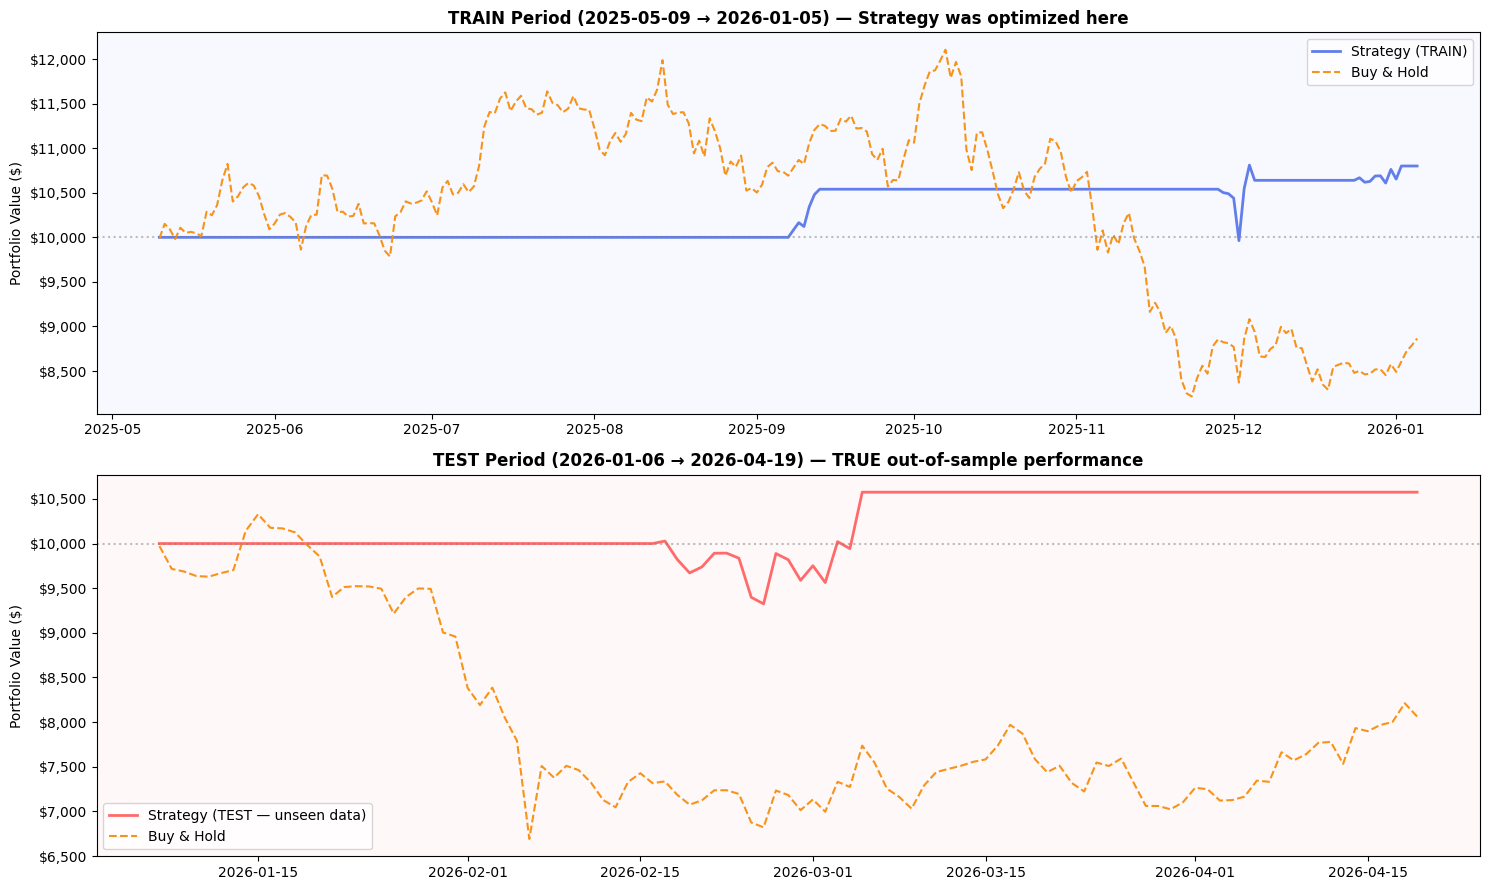

💾 Saved walk-forward chart


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=False)

# Train period
ax = axes[0]
ax.plot(eq_train.index, eq_train, color='#627eea', linewidth=2, label='Strategy (TRAIN)')
bnh_eq_train = equity_curve(train_data, pd.Series(1.0, index=train_data.index))
ax.plot(bnh_eq_train.index, bnh_eq_train, color='#f7931a', linewidth=1.5, linestyle='--', label='Buy & Hold')
ax.axhline(10000, color='grey', linestyle=':', alpha=0.5)
ax.set_title(f'TRAIN Period ({train_data.index[0].date()} → {train_data.index[-1].date()}) — Strategy was optimized here', fontweight='bold')
ax.set_ylabel('Portfolio Value ($)')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_facecolor('#f8f9ff')

# Test period
ax2 = axes[1]
ax2.plot(eq_test_strat.index, eq_test_strat, color='#ff6b6b', linewidth=2, label='Strategy (TEST — unseen data)')
ax2.plot(eq_test_bnh.index,   eq_test_bnh,   color='#f7931a', linewidth=1.5, linestyle='--', label='Buy & Hold')
ax2.axhline(10000, color='grey', linestyle=':', alpha=0.5)
ax2.set_title(f'TEST Period ({test_data.index[0].date()} → {test_data.index[-1].date()}) — TRUE out-of-sample performance', fontweight='bold')
ax2.set_ylabel('Portfolio Value ($)')
ax2.legend()
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.set_facecolor('#fff8f8')

plt.tight_layout()
plt.savefig(f'{config.RESULTS_DIR}/walk_forward_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved walk-forward chart')

## ✅ Notebook 05 Complete!

**What you proved (or disproved):**
- Whether your combined signal works on data it's never seen
- The difference between in-sample optimization and out-of-sample truth
- How professional quants validate strategies before risking real capital

**Next: Notebook 06** — Add transaction costs and trade BTC + ETH + SOL as a portfolio simultaneously.